<a href="https://colab.research.google.com/github/divyavanirambabu01/cv-lab/blob/main/exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
def show_comparison(original,blur3,blur5,blur7):
  plt.figure(figsize=(12,10))
  plt.subplot(2,2,1)
  plt.imshow(original,cmap="gray")
  plt.title('Original Grayscale Image')
  plt.axis('off')
  plt.subplot(2,2,2)
  plt.imshow(blur3,cmap="gray")
  plt.title("Average Filter(5x5)")
  plt.axis('off')
  plt.subplot(2,2,3)
  plt.imshow(blur5,cmap="gray")
  plt.title("Average Filter(5x5)")
  plt.axis('off')
  plt.subplot(2,2,4)
  plt.imshow(blur7,cmap="gray")
  plt.title("Average Filter(5x5)")
  plt.axis('off')

  plt.tight_layout()
  plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def apply_and_display_manual_filter(image, kernel, title="Filtered Image (Manual Convolution)"):
    """Applies a given kernel to an image using manual convolution and displays the result."""
    image_np = np.array(image)
    k_s = kernel.shape[0]  # Assuming a square kernel

    rows, cols = image_np.shape
    # Calculate output image dimensions based on valid convolution (no padding)
    output_rows = rows - k_s + 1
    output_cols = cols - k_s + 1

    filtered_img = np.zeros((output_rows, output_cols))

    for i in range(output_rows):
        for j in range(output_cols):
            image_window = image_np[i : i + k_s, j : j + k_s]
            filtered_img[i, j] = np.sum(image_window * kernel)

    print(f"{title}:")
    plt.imshow(filtered_img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
img=cv2.imread('/content/tiger',0)

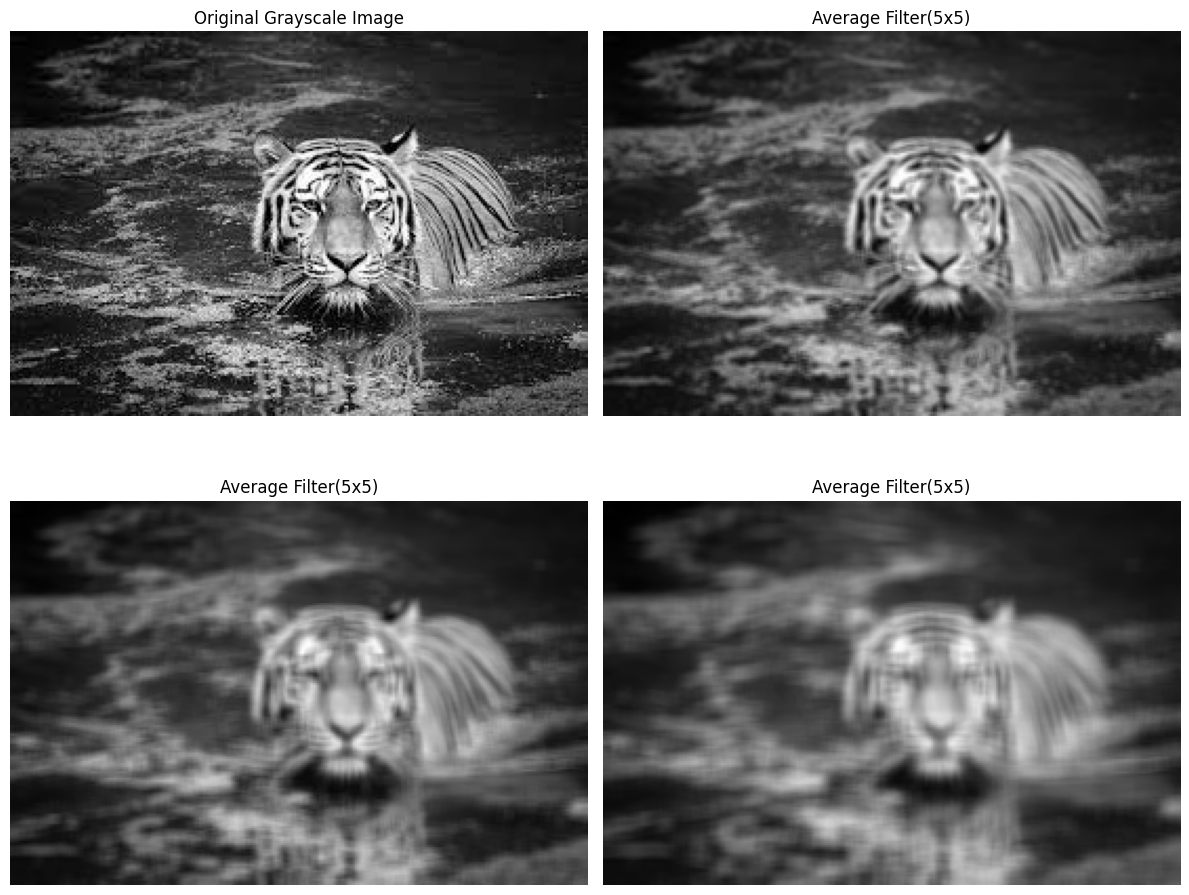

In [ ]:
if img is None:
  print("ERROR: IMAGE NOT FOUND")
else:
  kernal_3x3=np.ones((3,3),np.float32)/9
  kernal_5x5=np.ones((5,5),np.float32)/25
  kernal_7x7=np.ones((7,7),np.float32)/49
  blur_3x3=cv2.filter2D(img,-1,kernal_3x3)
  blur_5x5=cv2.filter2D(img,-1,kernal_5x5)
  blur_7x7=cv2.filter2D(img,-1,kernal_7x7)
  show_comparison(img,blur_3x3,blur_5x5,blur_7x7)

In [ ]:
plt.savefig("img.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
import cv2
img=cv2.imread('/content/cv3',0)

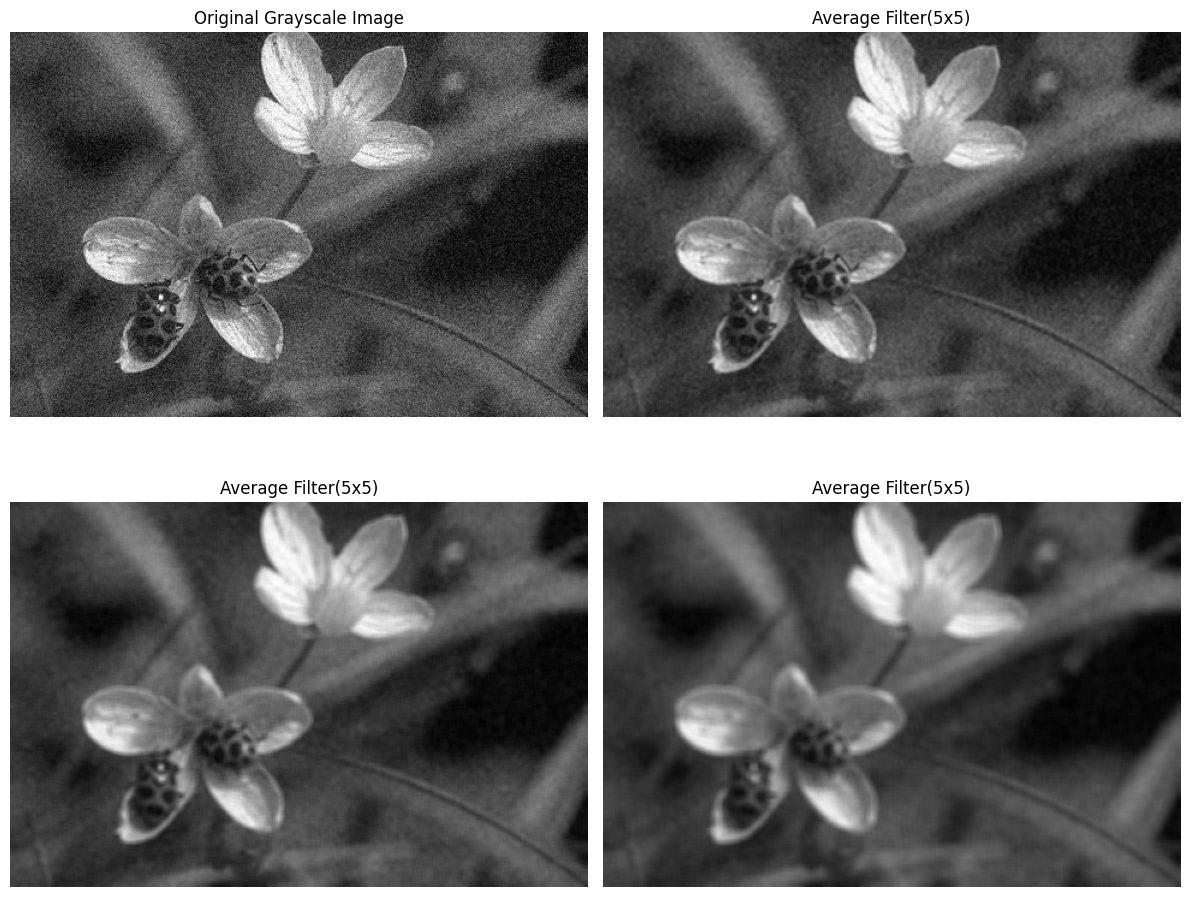

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def show_comparison(original,blur3,blur5,blur7):
  plt.figure(figsize=(12,10))
  plt.subplot(2,2,1)
  plt.imshow(original,cmap="gray")
  plt.title('Original Grayscale Image')
  plt.axis('off')
  plt.subplot(2,2,2)
  plt.imshow(blur3,cmap="gray")
  plt.title("Average Filter(5x5)")
  plt.axis('off')
  plt.subplot(2,2,3)
  plt.imshow(blur5,cmap="gray")
  plt.title("Average Filter(5x5)")
  plt.axis('off')
  plt.subplot(2,2,4)
  plt.imshow(blur7,cmap="gray")
  plt.title("Average Filter(5x5)")
  plt.axis('off')

  plt.tight_layout()
  plt.show()

if img is None:
  print("ERROR: IMAGE NOT FOUND")
else:
  kernal_3x3=np.ones((3,3),np.float32)/9
  kernal_5x5=np.ones((5,5),np.float32)/25
  kernal_7x7=np.ones((7,7),np.float32)/49
  blur_3x3=cv2.filter2D(img,-1,kernal_3x3)
  blur_5x5=cv2.filter2D(img,-1,kernal_5x5)
  blur_7x7=cv2.filter2D(img,-1,kernal_7x7)
  show_comparison(img,blur_3x3,blur_5x5,blur_7x7)

Filtered Image (NumPy):
[[56.44444444 59.77777778 59.33333333 ... 32.55555556 35.22222222
  34.22222222]
 [54.66666667 62.77777778 63.66666667 ... 34.66666667 34.55555556
  29.33333333]
 [55.22222222 62.55555556 62.44444444 ... 31.         30.22222222
  24.77777778]
 ...
 [78.11111111 74.66666667 72.88888889 ... 54.33333333 55.33333333
  62.11111111]
 [75.88888889 74.66666667 72.22222222 ... 62.77777778 54.55555556
  49.44444444]
 [72.11111111 75.11111111 71.55555556 ... 75.55555556 64.33333333
  48.77777778]]


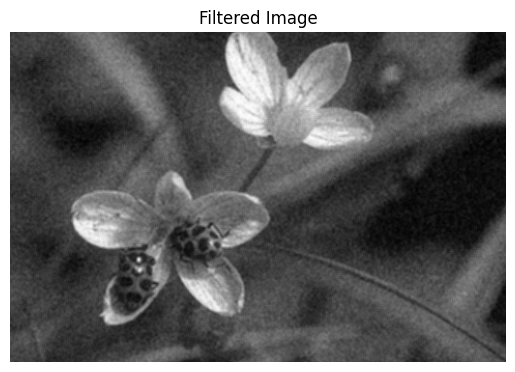

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
image_np = np.array(img)
kernel = np.ones((3, 3)) / 9

k_s = 3

rows, cols = image_np.shape
output_rows = rows - k_s + 1
output_cols = cols - k_s + 1

filtered_img = np.zeros((output_rows, output_cols))

for i in range(output_rows):
    for j in range(output_cols):
        image_window = image_np[i : i + k_s, j : j + k_s]

        filtered_img[i, j] = np.sum(image_window * kernel)

print("Filtered Image (NumPy):")
print(filtered_img)
plt.imshow(filtered_img, cmap='gray')
plt.title('Filtered Image')
plt.axis('off')
plt.show()

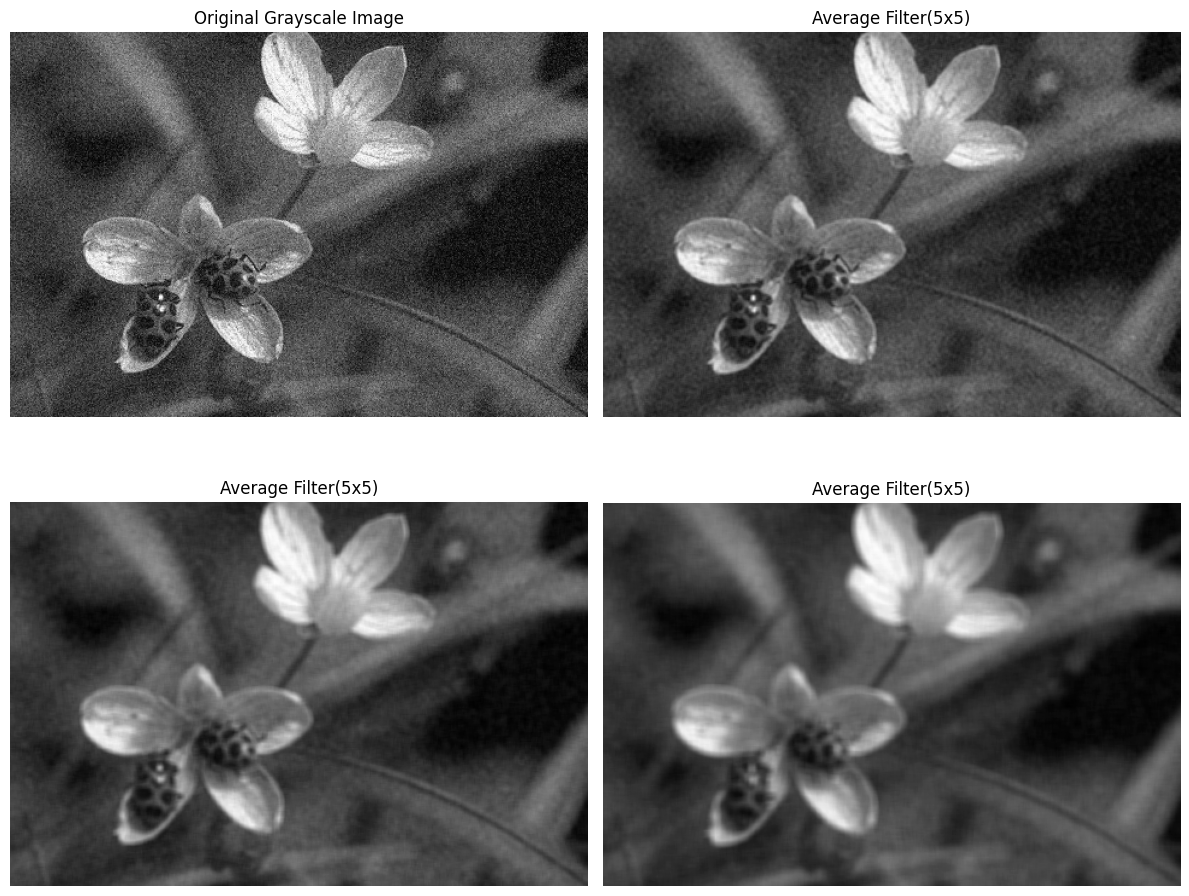

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _local_manual_convolve(image, kernel):
    """Applies a given kernel to an image using manual convolution and returns the result."""
    # Convert image to float32 for accurate calculations during convolution
    image_np = np.array(image, dtype=np.float32)
    k_s = kernel.shape[0]  # Assuming a square kernel

    rows, cols = image_np.shape
    # Calculate output image dimensions based on valid convolution (no padding)
    output_rows = rows - k_s + 1
    output_cols = cols - k_s + 1

    # Initialize the filtered image with zeros (float type for intermediate sums)
    filtered_img = np.zeros((output_rows, output_cols), dtype=np.float32)

    # Perform convolution
    for i in range(output_rows):
        for j in range(output_cols):
            image_window = image_np[i : i + k_s, j : j + k_s]
            filtered_img[i, j] = np.sum(image_window * kernel)
    return filtered_img

# Check if img is loaded before proceeding
if img is None:
  print("ERROR: IMAGE NOT FOUND. Please ensure an image is loaded into the 'img' variable.")
else:
  # Define different sized kernels for manual blurring
  kernel_3x3_manual = np.ones((3,3),np.float32)/9
  kernel_5x5_manual = np.ones((5,5),np.float32)/25
  kernel_7x7_manual = np.ones((7,7),np.float32)/49

  # Apply the manual filters using the local convolution function
  # Convert the output back to uint8 for display purposes
  manual_blur_3x3 = _local_manual_convolve(img, kernel_3x3_manual).astype(np.uint8)
  manual_blur_5x5 = _local_manual_convolve(img, kernel_5x5_manual).astype(np.uint8)
  manual_blur_7x7 = _local_manual_convolve(img, kernel_7x7_manual).astype(np.uint8)

  # Display the comparison of original and manually blurred images using the existing show_comparison function
  show_comparison(img, manual_blur_3x3, manual_blur_5x5, manual_blur_7x7)

Now that we have a reusable function for manual convolution, let's apply it to the current image (`img`) using a 3x3 kernel:

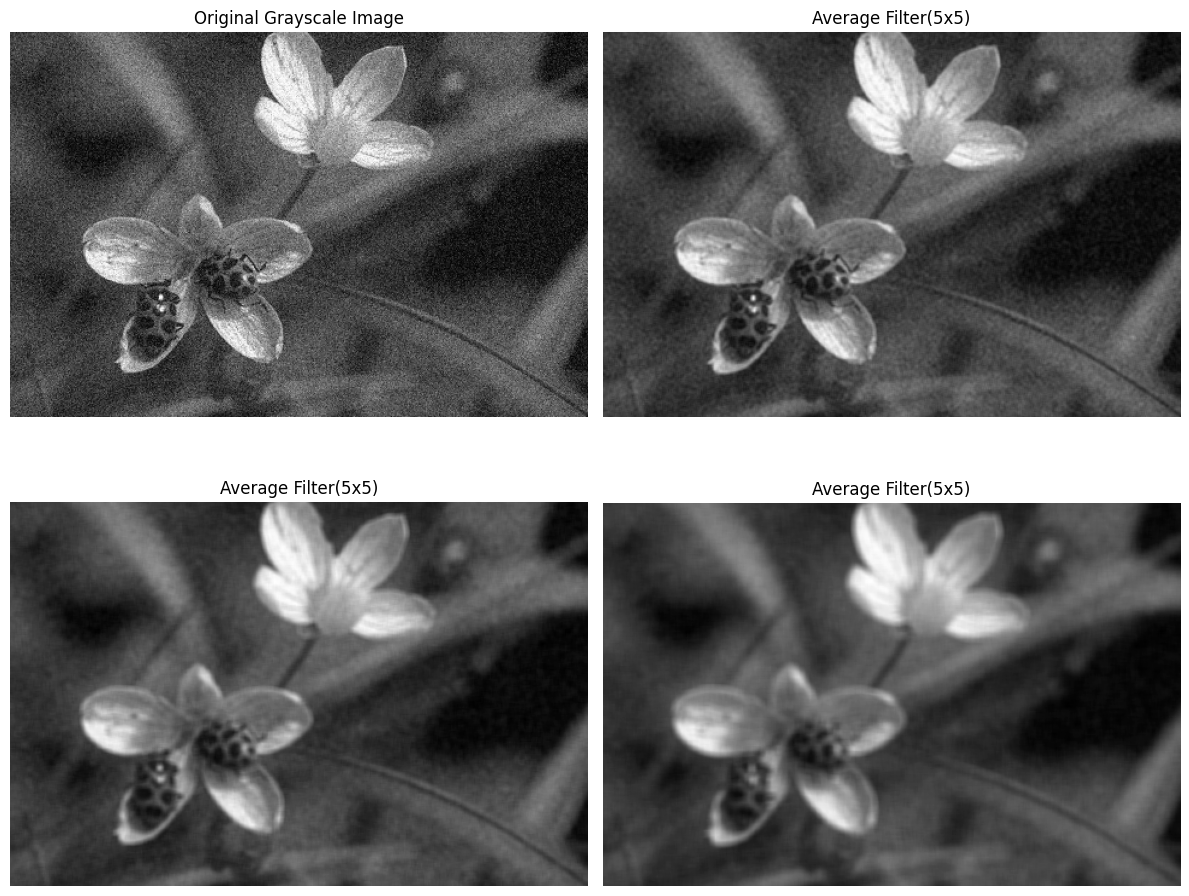

In [ ]:
if img is None:
  print("ERROR: IMAGE NOT FOUND. Please ensure an image is loaded into the 'img' variable.")
else:
  # Define different sized kernels for manual blurring
  kernel_3x3_manual = np.ones((3,3),np.float32)/9
  kernel_5x5_manual = np.ones((5,5),np.float32)/25
  kernel_7x7_manual = np.ones((7,7),np.float32)/49

  # Apply the manual filters
  # Ensure the image passed to manual_convolve is float type for consistent operations
  # and then converted back to uint8 if necessary for display, as show_comparison expects.
  manual_blur_3x3 = manual_convolve(img.astype(np.float32), kernel_3x3_manual).astype(np.uint8)
  manual_blur_5x5 = manual_convolve(img.astype(np.float32), kernel_5x5_manual).astype(np.uint8)
  manual_blur_7x7 = manual_convolve(img.astype(np.float32), kernel_7x7_manual).astype(np.uint8)

  # Display the comparison of original and manually blurred images
  show_comparison(img, manual_blur_3x3, manual_blur_5x5, manual_blur_7x7)

Filtered Image (Manual, 3x3 kernel):


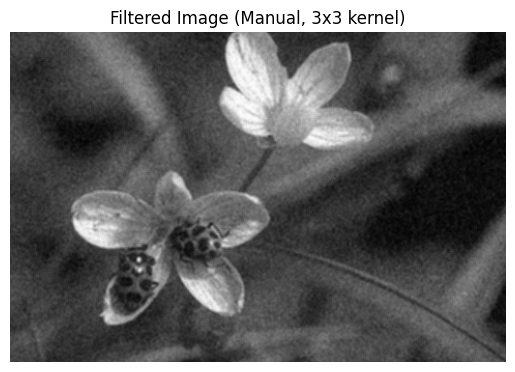

In [ ]:
kernel_3x3 = np.ones((3, 3)) / 9
apply_and_display_manual_filter(img, kernel_3x3, title='Filtered Image (Manual, 3x3 kernel)')

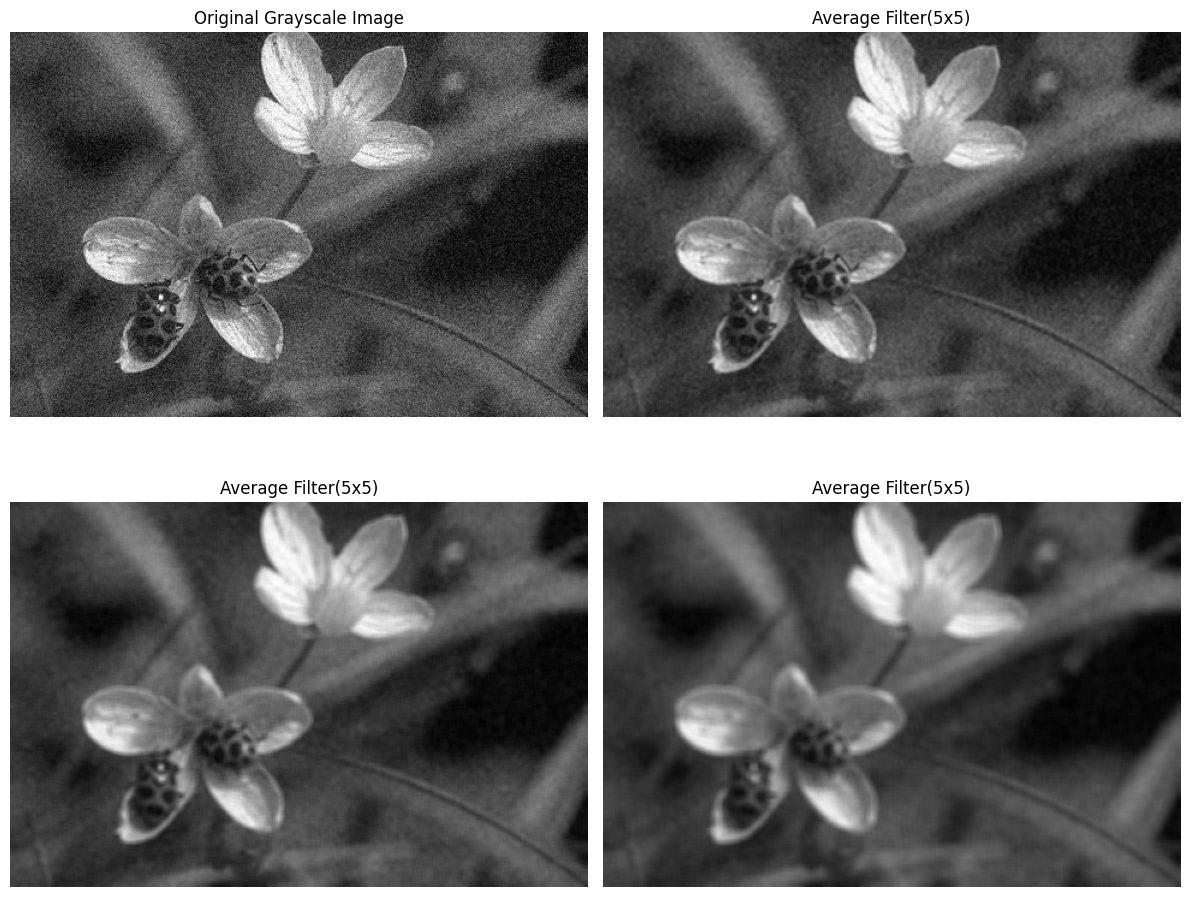

In [ ]:
if img is None:
  print("ERROR: IMAGE NOT FOUND. Please ensure an image is loaded into the 'img' variable.")
else:
  # Define different sized kernels for blurring
  kernel_3x3_avg = np.ones((3,3),np.float32)/9
  kernel_5x5_avg = np.ones((5,5),np.float32)/25
  kernel_7x7_avg = np.ones((7,7),np.float32)/49

  # Apply the filters
  blur_3x3 = cv2.filter2D(img,-1,kernel_3x3_avg)
  blur_5x5 = cv2.filter2D(img,-1,kernel_5x5_avg)
  blur_7x7 = cv2.filter2D(img,-1,kernel_7x7_avg)

  # Display the comparison of original and blurred images
  show_comparison(img, blur_3x3, blur_5x5, blur_7x7)